In [4]:
import pandas as pd
import json

# Load the dataset
file_path = '../diff_case_claims_with_negatives_fixed.csv'
df = pd.read_csv(file_path)

print(f"Dataset loaded. Shape: {df.shape}")
display(df.head())

Dataset loaded. Shape: (12310, 10)


,claim,case_name,judgement,explanation,raw_output,type,overruling_case,fact_id,label,is_negation
0,The Constitution does not recognize a right to...,"[""Roe v. Wade""]",consistent,The case evidence explicitly states that the C...,"```json\n{\n ""explanation"": ""The case evide...",none,NaN,0,0,True
1,The Constitution protects a person's right to ...,"[""Roe v. Wade""]",consistent,The case evidence explicitly states that the C...,"```json\n{\n ""explanation"": ""The case evide...",none,NaN,0,1,False
2,States are permitted to impose regulations on ...,"[""Roe v. Wade""]",consistent,"The case evidence explicitly states that ""In t...","```json\n{\n ""explanation"": ""The case evide...",none,NaN,1,0,True
3,States cannot restrict abortion during the fir...,"[""Roe v. Wade""]",consistent,"The case evidence explicitly states that ""In t...","```json\n{\n ""explanation"": ""The case evide...",none,NaN,1,1,False
4,"During the second three months of pregnancy, s...","[""Roe v. Wade""]",consistent,The case evidence states that in the second tr...,"```json\n{\n ""explanation"": ""The case evide...",none,NaN,2,1,False


In [2]:
# Summary Statistics

print("--- General Statistics ---")
print(f"Total Samples: {len(df)}")
print(f"Unique Fact IDs: {df['fact_id'].nunique()}")
print(f"Unique Cases: {df['case_name'].nunique()}")

# print("\n--- Class Distribution ---")
# print(df['class'].value_counts())
# print(df['class'].value_counts(normalize=True))

print("\n--- Label Distribution ---")
print(df['label'].value_counts())

print("\n--- Type Distribution ---")
print(df['type'].value_counts())

--- General Statistics ---
Total Samples: 12310
Unique Fact IDs: 6401
Unique Cases: 3381

--- Label Distribution ---
label
1    6401
0    5909
Name: count, dtype: int64

--- Type Distribution ---
type
none         11378
overruled      492
confirmed      440
Name: count, dtype: int64


In [3]:
# Examples

def print_example(fact_id):
    rows = df[df['fact_id'] == fact_id]
    print(f"--- Fact ID: {fact_id} ---")
    # Print shared metadata from first row
    first_row = rows.iloc[0]
    print(f"Case: {first_row['case_name']}")
    print(f"Facts: {first_row['facts'][:200]}..." if isinstance(first_row['facts'], str) else f"Facts: {first_row['facts']}")
    print(f"Question: {first_row['question']}")
    print(f"Conclusion: {first_row['conclusion'][:200]}..." if isinstance(first_row['conclusion'], str) else f"Conclusion: {first_row['conclusion']}")
    print("-" * 20)
    
    for _, row in rows.iterrows():
        # print(f"Class: {row['class']} (Label {row['label']})")
        print(f"Type: {row['type']}")
        print(f"Claim: {row['claim']}")
        print("-" * 10)
    print("=" * 30)

print("--- Random Example ---")
random_id = df['fact_id'].sample(1).iloc[0]
print_example(random_id)

print("\n--- Overruling Example ---")
overruling_ids = df[df['class'] == 'Overruled']['fact_id'].unique()
if len(overruling_ids) > 0:
    print_example(overruling_ids[0])

print("\n--- Supported Example ---")
supported_ids = df[df['class'] == 'Supported']['fact_id'].unique()
if len(supported_ids) > 0:
    print_example(supported_ids[0])

--- Random Example ---
--- Fact ID: 2736 ---
Case: ["Meyer v. Holley"]


KeyError: 'facts'

In [4]:
import numpy as np
import json

# 1. Helper to get case name
def get_case_name(x):
    try:
        val = json.loads(x)
        if isinstance(val, list) and len(val) > 0:
            return val[0]
        return str(x)
    except:
        return str(x)

# 2. Prepare sampling pool
# We need to ensure that for every case in the test set, there is at least one claim left in the training set.
# Strategy: For each case, reserve 1 fact_id for training. The rest can be sampled.

# Get unique fact_ids and their case
# Since a fact_id has 2 rows (pos/neg) with same case, we just take the first
unique_facts = df.drop_duplicates(subset=['fact_id'])[['fact_id', 'case_name']].copy()
unique_facts['clean_case'] = unique_facts['case_name'].apply(get_case_name)

# Group by case
case_counts = unique_facts['clean_case'].value_counts()
valid_cases = case_counts[case_counts > 1].index

print(f"Total cases: {len(case_counts)}")
print(f"Cases with >1 claim (eligible for split): {len(valid_cases)}")

# Filter facts belonging to valid cases
valid_facts = unique_facts[unique_facts['clean_case'].isin(valid_cases)]

# Reserve one per case
reserved_ids = valid_facts.groupby('clean_case')['fact_id'].apply(lambda x: np.random.choice(x, 1)[0])
reserved_set = set(reserved_ids)

# Available pool
available_pool = valid_facts[~valid_facts['fact_id'].isin(reserved_set)]['fact_id'].values

print(f"Total unique fact_ids: {len(unique_facts)}")
print(f"Reserved fact_ids (1 per valid case): {len(reserved_set)}")
print(f"Available for sampling: {len(available_pool)}")

# 3. Sample
n_sample = 1000
if len(available_pool) < n_sample:
    print(f"Warning: Only {len(available_pool)} available fact_ids. Sampling all.")
    n_sample = len(available_pool)

sampled_ids = np.random.choice(available_pool, n_sample, replace=False)

# 4. Select one claim per fact_id (randomly positive or negative)
subsample = df[df['fact_id'].isin(sampled_ids)].groupby('fact_id').sample(n=1)

# 5. Randomize order
subsample = subsample.sample(frac=1).reset_index(drop=True)

# 6. Statistics
print(f"--- Subsample Statistics (n={len(subsample)}) ---")

print("\nLabel Distribution (Positive vs Negative):")
print(subsample['label'].value_counts())
print(subsample['label'].value_counts(normalize=True))

print("\nType Distribution:")
print(subsample['type'].value_counts())
print(subsample['type'].value_counts(normalize=True))

# Verify uniqueness
print(f"\nAre all fact_ids unique? {subsample['fact_id'].is_unique}")

# Display head
display(subsample.head())

Total cases: 2915
Cases with >1 claim (eligible for split): 2062
Total unique fact_ids: 6401
Reserved fact_ids (1 per valid case): 2062
Available for sampling: 3486
--- Subsample Statistics (n=1000) ---

Label Distribution (Positive vs Negative):
label
1    545
0    455
Name: count, dtype: int64
label
1    0.545
0    0.455
Name: proportion, dtype: float64

Type Distribution:
type
none         903
overruled     64
confirmed     33
Name: count, dtype: int64
type
none         0.903
overruled    0.064
confirmed    0.033
Name: proportion, dtype: float64

Are all fact_ids unique? True


,claim,case_name,judgement,explanation,raw_output,type,overruling_case,fact_id,label,is_negation
0,Courts of appeals can review EPA pollution reg...,"[""E. I. du Pont de Nemours & Company v. Train""]",NaN,NaN,NaN,overruled,National Association of Manufacturers v. Depar...,6150,1,False
1,Bribing officials of an organization that rece...,"[""Fischer v. United States""]",consistent,The case evidence details that Jeffrey Fischer...,"```json\n{\n ""explanation"": ""The case evide...",none,NaN,2315,1,False
2,Religious and charitable organizations are usu...,"[""New York State Club Association Inc. v. City...",consistent,The case evidence explicitly states that the C...,"```json\n{\n ""explanation"": ""The case evide...",none,NaN,1235,1,False
3,The Double Jeopardy Clause applies to both dea...,"[""Monge v. California""]",consistent,The case evidence explicitly states that the C...,"```json\n{\n ""explanation"": ""The case evide...",none,NaN,2042,0,True
4,Government positions with authority from local...,"[""Financial Oversight and Management Board for...",consistent,The claim states that government positions wit...,"```json\n{\n ""explanation"": ""The claim stat...",none,NaN,5738,1,False


In [5]:
# Process Data
def process_data(df, exclude_overruling=False):
    # Print first example of case_name
    print(f"First case_name raw: {df['case_name'].iloc[0]}")
    
    # Parse case_name (it's a JSON list string)
    df['clean_case_name'] = df['case_name'].apply(lambda x: json.loads(x)[0] if isinstance(x, str) and x.startswith('[') else x)
    
    # Load metadata
    meta_path = '../clean_data_with_details.csv'
    meta_df = pd.read_csv(meta_path)
    
    # Merge
    # We need facts, api_question, api_conclusion from metadata
    # Match clean_case_name with name
    merged = df.merge(meta_df[['name', 'facts', 'api_question', 'api_conclusion']], 
                      left_on='clean_case_name', right_on='name', how='left')
    
    # Rename columns
    merged = merged.rename(columns={'api_question': 'question', 'api_conclusion': 'conclusion'})
    
    # Create class column
    def get_class(row):
        if row['type'] == 'overruled':
            return 'Overruled'
        elif row['is_negation']:
            return 'Refuted'
        else:
            return 'Supported'
            
    merged['class'] = merged.apply(get_class, axis=1)
    
    # Update label to match class (0: Refuted, 1: Supported, 2: Overruled)
    label_map = {'Refuted': 0, 'Supported': 1, 'Overruled': 2}
    merged['label'] = merged['class'].map(label_map)
    
    # Drop columns
    # Note: clean_case_name is kept as it is used in subsequent cells
    cols_to_drop = ['judgement', 'explanation', 'raw_output', 'is_negation', 'name']
    merged = merged.drop(columns=cols_to_drop, errors='ignore')
    
    return merged

# Apply processing
df = process_data(df, exclude_overruling=True)

print(f"Processed dataset shape: {df.shape}")
display(df.head())
print("\nClass Distribution:")
print(df['class'].value_counts())

First case_name raw: ["Roe v. Wade"]
Processed dataset shape: (12581, 11)


,claim,case_name,type,overruling_case,fact_id,label,clean_case_name,facts,question,conclusion,class
0,The Constitution does not recognize a right to...,"[""Roe v. Wade""]",none,NaN,0,0,Roe v. Wade,"In 1970, Jane Roe (a fictional name used in co...",Does the Constitution recognize a woman's righ...,Inherent in the Due Process Clause of the Four...,Refuted
1,The Constitution protects a person's right to ...,"[""Roe v. Wade""]",none,NaN,0,1,Roe v. Wade,"In 1970, Jane Roe (a fictional name used in co...",Does the Constitution recognize a woman's righ...,Inherent in the Due Process Clause of the Four...,Supported
2,States are permitted to impose regulations on ...,"[""Roe v. Wade""]",none,NaN,1,0,Roe v. Wade,"In 1970, Jane Roe (a fictional name used in co...",Does the Constitution recognize a woman's righ...,Inherent in the Due Process Clause of the Four...,Refuted
3,States cannot restrict abortion during the fir...,"[""Roe v. Wade""]",none,NaN,1,1,Roe v. Wade,"In 1970, Jane Roe (a fictional name used in co...",Does the Constitution recognize a woman's righ...,Inherent in the Due Process Clause of the Four...,Supported
4,"During the second three months of pregnancy, s...","[""Roe v. Wade""]",none,NaN,2,1,Roe v. Wade,"In 1970, Jane Roe (a fictional name used in co...",Does the Constitution recognize a woman's righ...,Inherent in the Due Process Clause of the Four...,Supported



Class Distribution:
class
Refuted      6036
Supported    6036
Overruled     509
Name: count, dtype: int64


In [9]:
# Sample 1000 unique fact_ids
n_sample = 1000

# Re-calculate available pool based on the processed df
unique_facts = df.drop_duplicates(subset=['fact_id'])[['fact_id', 'clean_case_name']].copy()

# Reserve one per case
# We reserve one claim per case for training/context. The rest are available for sampling.
reserved_ids = unique_facts.groupby('clean_case_name')['fact_id'].apply(lambda x: np.random.choice(x, 1)[0])
reserved_set = set(reserved_ids)

# Available pool
available_pool = unique_facts[~unique_facts['fact_id'].isin(reserved_set)]['fact_id'].values

print(f"Total unique fact_ids: {len(unique_facts)}")
print(f"Reserved fact_ids (1 per case): {len(reserved_set)}")
print(f"Available for sampling: {len(available_pool)}")

if len(available_pool) < n_sample:
    print(f"Warning: Only {len(available_pool)} available fact_ids. Sampling all.")
    n_sample = len(available_pool)

sampled_ids = np.random.choice(available_pool, n_sample, replace=False)

# Select one claim per fact_id
sampled_df = df[df['fact_id'].isin(sampled_ids)].groupby('fact_id').sample(n=1)

# Randomize order
sampled_df = sampled_df.sample(frac=1).reset_index(drop=True)

print(f"Sampled shape: {sampled_df.shape}")
print(f"Unique fact_ids: {sampled_df['fact_id'].nunique()}")

# Save to Excel
output_path = 'sampled_claims_1000.xlsx'
sampled_df.to_excel(output_path, index=False)
print(f"Saved to {output_path}")

display(sampled_df.head())

Total unique fact_ids: 6401
Reserved fact_ids (1 per case): 2915
Available for sampling: 3486
Sampled shape: (1000, 11)
Unique fact_ids: 1000
Saved to sampled_claims_1000.xlsx


,claim,case_name,type,overruling_case,fact_id,label,clean_case_name,facts,question,conclusion,class
0,Courts must evaluate whether mutual fund fees ...,"[""Jones v. Harris Associates L.P.""]",none,NaN,3628,1,Jones v. Harris Associates L.P.,Plaintiffs were investors in several mutual fu...,Did the Seventh Circuit err in holding that cl...,Yes. The Supreme Court held that the Seventh C...,Supported
1,Replacing county-wide elections with single-me...,"[""Rogers v. Lodge""]",none,NaN,742,1,Rogers v. Lodge,"Eight black citizens of Burke County, Georgia,...",Did the system of elections violate the Fourte...,"In a 6-to-3 decision, the Court held that the ...",Supported
2,The Fifth Amendment takings clause does not cr...,"[""San Remo Hotel, L.P. v. City and County of S...",overruled,Stewart v. Smith,6184,2,"San Remo Hotel, L.P. v. City and County of San...",The owners and operators of a hotel in San Fra...,Should federal courts make an exception to the...,No. In a 9-0 judgment delivered by Justice Joh...,Overruled
3,ERISA explicitly permits states to require emp...,"[""UNUM Life Insurance Company of America v. Wa...",none,NaN,2219,0,UNUM Life Insurance Company of America v. Ward,UNUM Life Insurance Company of America (UNUM) ...,Does the Employee Retirement Income Security A...,"Yes and no. In a unanimous opinion, delivered ...",Refuted
4,Police are legally prohibited from entering a ...,"[""Michigan v. Fisher""]",none,NaN,438,0,Michigan v. Fisher,Jeremy Fisher was charged with assault with a ...,Did the Michigan Court of Appeals err when it ...,"Yes. In a per curiam opinion, the Supreme Cour...",Refuted


In [11]:
sampled_df["class"].value_counts()

class
Supported    472
Refuted      456
Overruled     72
Name: count, dtype: int64

In [15]:
import string

# Define "normal" characters: letters, numbers, spaces, and basic punctuation
# We exclude characters that are typically fine in English text
normal_chars = set(string.ascii_letters + string.digits + string.whitespace + ".,;:'\"?!-()")

print("--- Claims with weird/non-standard characters ---")
found_count = 0
all_weird_chars = set()

for idx, row in df.iterrows():
    claim = row['claim']
    if not isinstance(claim, str):
        continue
        
    # Find characters not in normal set
    weird_chars = [c for c in claim if c not in normal_chars]
    
    if weird_chars:
        unique_weird = sorted(list(set(weird_chars)))
        all_weird_chars.update(unique_weird)
        print(f"Row {idx} | Weird chars: {unique_weird} | Claim: {claim}")
        found_count += 1

print(f"\nTotal claims with weird characters: {found_count}")
print(f"All unique weird characters found: {sorted(list(all_weird_chars))}")

--- Claims with weird/non-standard characters ---
Row 67 | Weird chars: ['’'] | Claim: Speech that is offensive and likely to incite a disturbance, even without an immediate threat of physical harm, is not protected by the First Amendment, and the Cantwells’ anti-Catholic message constituted a sufficient disturbance to justify their convictions.
Row 87 | Weird chars: ['*'] | Claim: Government-provided licenses with significant economic value, such as a liquor license, *do* transform a private business into a government entity for constitutional purposes, requiring adherence to the Equal Protection Clause.
Row 90 | Weird chars: ['*'] | Claim: The government's requirement that journalists disclose confidential sources during criminal investigations *does* violate the First Amendment, as it undermines the freedom of the press and creates a chilling effect on the ability of journalists to gather and report information.
Row 133 | Weird chars: ['*'] | Claim: Private property open to the publ

In [3]:
# Remove '*' characters from the original CSV file
original_path = '../diff_case_claims_with_negatives_fixed_rewritten.csv'
print(f"Reading from {original_path}...")
df_original = pd.read_csv(original_path)

# Count occurrences before
# Handle potential non-string values by converting to str temporarily for counting, or just use str accessor which handles NaNs
count_before = df_original['claim'].astype(str).str.count('\*').sum()
print(f"Total '*' characters found: {count_before}")

# Remove '*'
# We use regex=False to treat '*' as a literal character
df_original['claim'] = df_original['claim'].str.replace('*', '', regex=False)

# Save back
df_original.to_csv(original_path, index=False)
print(f"Saved cleaned data to {original_path}")

Reading from ../diff_case_claims_with_negatives_fixed_rewritten.csv...
Total '*' characters found: 872
Saved cleaned data to ../diff_case_claims_with_negatives_fixed_rewritten.csv


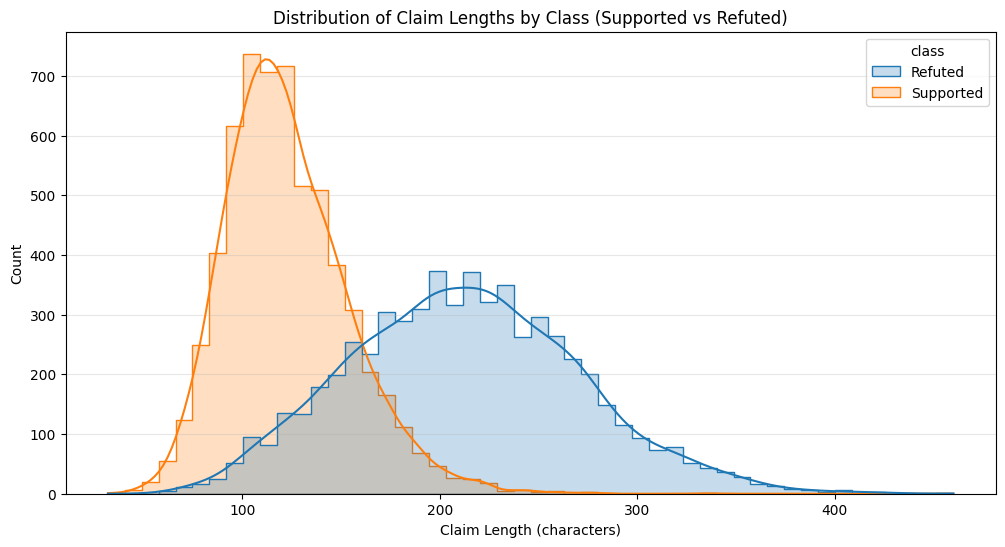

            count        mean        std   min    25%    50%    75%    max
class                                                                     
Refuted    6036.0  212.725315  58.584307  59.0  171.0  212.0  251.0  460.0
Supported  6036.0  122.674288  31.084847  32.0  101.0  119.0  141.0  334.0


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out Overruled
plot_df = df[df['class'] != 'Overruled'].copy()

# Calculate length (character count)
plot_df['claim_length'] = plot_df['claim'].astype(str).str.len()

# Plot
plt.figure(figsize=(12, 6))
sns.histplot(data=plot_df, x='claim_length', hue='class', kde=True, element="step", bins=50)
plt.title('Distribution of Claim Lengths by Class (Supported vs Refuted)')
plt.xlabel('Claim Length (characters)')
plt.ylabel('Count')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Print summary stats
print(plot_df.groupby('class')['claim_length'].describe())

Rewritten dataset loaded. Shape: (12310, 11)


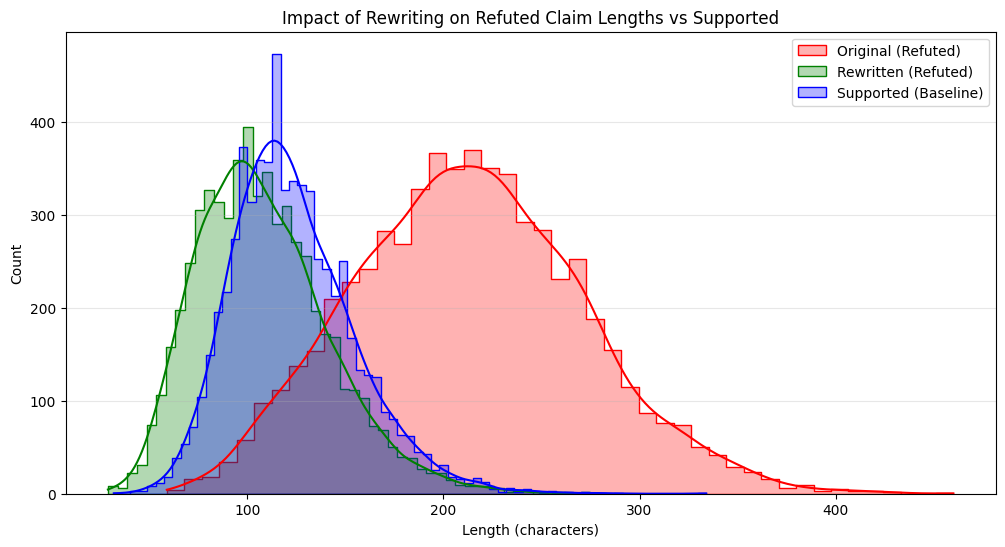

Refuted Lengths Summary:
       original_length  rewritten_length
count      5909.000000       5909.000000
mean        212.890675        108.191064
std          58.653977         33.871165
min          59.000000         29.000000
25%         171.000000         83.000000
50%         212.000000        104.000000
75%         252.000000        128.000000
max         460.000000        275.000000

Supported Lengths Summary:
            length
count  6401.000000
mean    123.507421
std      31.403572
min      32.000000
25%     102.000000
50%     120.000000
75%     142.000000
max     334.000000


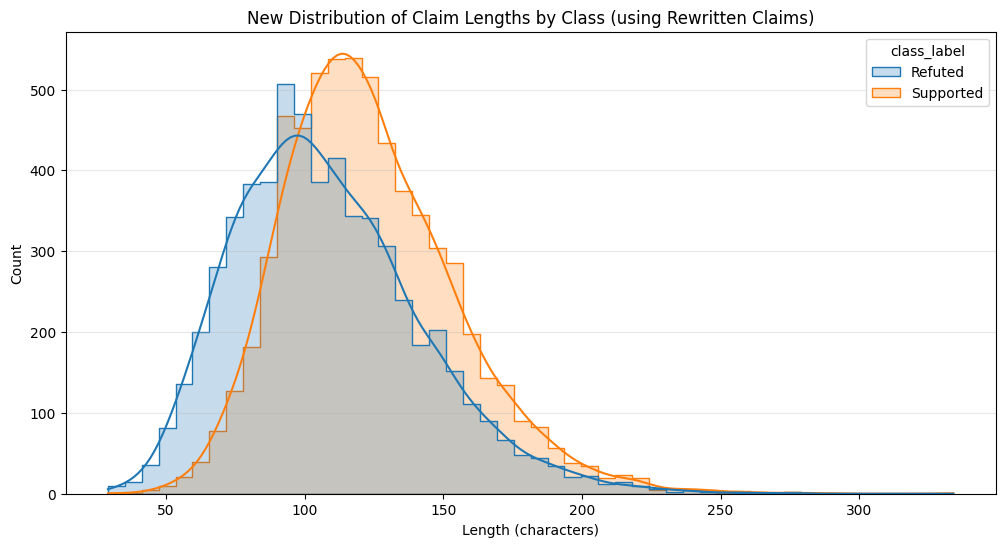

In [8]:
# Load the rewritten claims dataset
rewritten_path = '../diff_case_claims_rewritten.csv'
try:
    df_rewritten = pd.read_csv(rewritten_path)
    print(f"Rewritten dataset loaded. Shape: {df_rewritten.shape}")

    # 1. Comparison of Original vs Rewritten for Refuted claims
    # Assuming label 0 is Refuted
    refuted_mask = df_rewritten['label'] == 0
    refuted_df = df_rewritten[refuted_mask].copy()
    
    # Get Supported claims for baseline comparison
    supported_mask = df_rewritten['label'] == 1
    supported_df = df_rewritten[supported_mask].copy()

    refuted_df['original_length'] = refuted_df['claim'].astype(str).str.len()
    refuted_df['rewritten_length'] = refuted_df['rewritten_claim'].astype(str).str.len()
    supported_df['length'] = supported_df['claim'].astype(str).str.len()

    plt.figure(figsize=(12, 6))
    sns.histplot(x=refuted_df['original_length'], color='red', label='Original (Refuted)', kde=True, element="step", alpha=0.3)
    sns.histplot(x=refuted_df['rewritten_length'], color='green', label='Rewritten (Refuted)', kde=True, element="step", alpha=0.3)
    sns.histplot(x=supported_df['length'], color='blue', label='Supported (Baseline)', kde=True, element="step", alpha=0.3)
    
    plt.title('Impact of Rewriting on Refuted Claim Lengths vs Supported')
    plt.xlabel('Length (characters)')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    print("Refuted Lengths Summary:")
    print(refuted_df[['original_length', 'rewritten_length']].describe())
    print("\nSupported Lengths Summary:")
    print(supported_df[['length']].describe())

    # 2. New Distribution by Class
    df_rewritten['new_length'] = df_rewritten['rewritten_claim'].astype(str).str.len()
    # Map labels for plotting if class column is missing or needs update
    label_map = {0: 'Refuted', 1: 'Supported', 2: 'Overruled'}
    df_rewritten['class_label'] = df_rewritten['label'].map(label_map)

    plt.figure(figsize=(12, 6))
    # Filter out Overruled for cleaner comparison if desired, or keep them
    plot_data = df_rewritten[df_rewritten['class_label'] != 'Overruled']
    
    sns.histplot(data=plot_data, x='new_length', hue='class_label', kde=True, element="step", bins=50)
    plt.title('New Distribution of Claim Lengths by Class (using Rewritten Claims)')
    plt.xlabel('Length (characters)')
    plt.grid(axis='y', alpha=0.3)
    plt.show()
    
except FileNotFoundError:
    print(f"File not found: {rewritten_path}. Please run the rewrite script first.")

In [10]:
df_rewritten.head()

,claim,case_name,judgement,explanation,raw_output,type,overruling_case,fact_id,label,is_negation,rewritten_claim
0,The Constitution does not recognize a right to...,"[""Roe v. Wade""]",consistent,The case evidence explicitly states that the C...,"```json\n{\n ""explanation"": ""The case evide...",none,NaN,0,0,True,The Constitution does not protect the right to...
1,The Constitution protects a person's right to ...,"[""Roe v. Wade""]",consistent,The case evidence explicitly states that the C...,"```json\n{\n ""explanation"": ""The case evide...",none,NaN,0,1,False,The Constitution protects a person's right to ...
2,States are permitted to impose regulations on ...,"[""Roe v. Wade""]",consistent,"The case evidence explicitly states that ""In t...","```json\n{\n ""explanation"": ""The case evide...",none,NaN,1,0,True,The government may regulate abortion procedure...
3,States cannot restrict abortion during the fir...,"[""Roe v. Wade""]",consistent,"The case evidence explicitly states that ""In t...","```json\n{\n ""explanation"": ""The case evide...",none,NaN,1,1,False,States cannot restrict abortion during the fir...
4,"During the second three months of pregnancy, s...","[""Roe v. Wade""]",consistent,The case evidence states that in the second tr...,"```json\n{\n ""explanation"": ""The case evide...",none,NaN,2,1,False,"During the second three months of pregnancy, s..."


In [12]:
df_anno.head()

,claim,case_name,type,overruling_case,fact_id,label,clean_case_name,facts,question,conclusion,class,old_negation
0,Courts must evaluate whether mutual fund fees ...,"[""Jones v. Harris Associates L.P.""]",none,NaN,3628,1,Jones v. Harris Associates L.P.,Plaintiffs were investors in several mutual fu...,Did the Seventh Circuit err in holding that cl...,Yes. The Supreme Court held that the Seventh C...,Supported,None
1,Replacing county-wide elections with single-me...,"[""Rogers v. Lodge""]",none,NaN,742,1,Rogers v. Lodge,"Eight black citizens of Burke County, Georgia,...",Did the system of elections violate the Fourte...,"In a 6-to-3 decision, the Court held that the ...",Supported,None
2,The Fifth Amendment takings clause does not cr...,"[""San Remo Hotel, L.P. v. City and County of S...",overruled,Stewart v. Smith,6184,2,"San Remo Hotel, L.P. v. City and County of San...",The owners and operators of a hotel in San Fra...,Should federal courts make an exception to the...,No. In a 9-0 judgment delivered by Justice Joh...,Overruled,None
3,Federal law does not require states to permit ...,"[""UNUM Life Insurance Company of America v. Wa...",none,NaN,2219,0,UNUM Life Insurance Company of America v. Ward,UNUM Life Insurance Company of America (UNUM) ...,Does the Employee Retirement Income Security A...,"Yes and no. In a unanimous opinion, delivered ...",Refuted,None
4,Police may enter a home without a warrant when...,"[""Michigan v. Fisher""]",none,NaN,438,0,Michigan v. Fisher,Jeremy Fisher was charged with assault with a ...,Did the Michigan Court of Appeals err when it ...,"Yes. In a per curiam opinion, the Supreme Cour...",Refuted,None


In [1]:
# Update the annotated Excel file with rewritten claims
import os
import pandas as pd

anno_path = 'sampled_claims_1000_anno.xlsx'
rewritten_path = '../diff_case_claims_rewritten.csv'

if os.path.exists(anno_path) and os.path.exists(rewritten_path):
    print(f"Loading annotated data from {anno_path}...")
    df_anno = pd.read_excel(anno_path)
    
    print(f"Loading rewritten claims from {rewritten_path}...")
    df_rewritten = pd.read_csv(rewritten_path)
    
    # Filter for Refuted claims (label = 0) in the rewritten file
    refuted_df = df_rewritten[df_rewritten['label'] == 0]
    print(f"Total Refuted claims in rewritten file: {len(refuted_df)}")
    
    # Create a mapping from original claim text to rewritten claim text
    # This handles cases where fact_id might not match or be reliable
    claim_to_rewrite = refuted_df.set_index('claim')['rewritten_claim'].to_dict()
    
    # Initialize old_negation column if it doesn't exist
    if 'old_negation' not in df_anno.columns:
        df_anno['old_negation'] = None
        
    updated_annotated_count = 0
    updated_unannotated_count = 0
    
    # Iterate and update
    for idx, row in df_anno.iterrows():
        current_claim = row['claim']
        
        # Check if the current claim text exists in our mapping
        if current_claim in claim_to_rewrite:
            new_claim = claim_to_rewrite[current_claim]
            
            # Check if it's annotated (Rating is not empty/NaN)
            is_annotated = pd.notna(row.get('Rating'))
            
            if is_annotated:
                # For annotated claims:
                # 1. Move current claim to old_negation
                df_anno.at[idx, 'old_negation'] = current_claim
                # 2. Update claim with new text
                df_anno.at[idx, 'claim'] = new_claim
                updated_annotated_count += 1
            else:
                # For unannotated claims:
                # Just update the claim text if it changed
                if current_claim != new_claim:
                     df_anno.at[idx, 'claim'] = new_claim
                     updated_unannotated_count += 1
    
    print(f"Processing complete.")
    print(f"- Annotated claims updated (moved to old_negation): {updated_annotated_count}")
    print(f"- Unannotated claims updated (in place): {updated_unannotated_count}")
    
    # Save back
    output_path = 'sampled_claims_1000_anno_updated.xlsx'
    df_anno.to_excel(output_path, index=False)
    print(f"Saved updated file to {output_path}")
    
else:
    print("Files not found.")

Loading annotated data from sampled_claims_1000_anno.xlsx...
Loading rewritten claims from ../diff_case_claims_rewritten.csv...
Total Refuted claims in rewritten file: 5909
Processing complete.
- Annotated claims updated (moved to old_negation): 157
- Unannotated claims updated (in place): 287
Saved updated file to sampled_claims_1000_anno_updated.xlsx


In [2]:
# Update the larger dataset (diff_case_claims_with_negatives_fixed.csv) with rewritten claims
import os
import pandas as pd

large_dataset_path = '../diff_case_claims_with_negatives_fixed.csv'
rewritten_path = '../diff_case_claims_rewritten.csv'
output_path = '../diff_case_claims_with_negatives_fixed_rewritten.csv'

if os.path.exists(large_dataset_path) and os.path.exists(rewritten_path):
    print(f"Loading large dataset from {large_dataset_path}...")
    df_large = pd.read_csv(large_dataset_path)
    print(f"Large dataset shape: {df_large.shape}")
    
    print(f"Loading rewritten claims from {rewritten_path}...")
    df_rewritten = pd.read_csv(rewritten_path)
    
    # Filter for Refuted claims (label = 0) in the rewritten file
    # We assume these are the ones that were rewritten
    refuted_rewrites = df_rewritten[df_rewritten['label'] == 0]
    print(f"Rewritten Refuted claims count: {len(refuted_rewrites)}")
    
    # Create mapping: original_claim -> rewritten_claim
    # Using claim text as key as requested
    claim_map = refuted_rewrites.set_index('claim')['rewritten_claim'].to_dict()
    
    # Update the large dataset
    # We iterate or use map. Since we want to update "negatives" (Refuted), we can target them.
    # However, to be safe, we'll update any claim that matches a key in our map.
    
    # Count Refuted in large dataset before
    if 'label' in df_large.columns:
        refuted_count_large = len(df_large[df_large['label'] == 0])
        print(f"Refuted claims in large dataset: {refuted_count_large}")
    
    # Apply updates
    # Create a mask for rows where the claim is in our map
    mask = df_large['claim'].isin(claim_map)
    print(f"Found {mask.sum()} matching claims to update.")
    
    # Update those rows
    df_large.loc[mask, 'claim'] = df_large.loc[mask, 'claim'].map(claim_map)
    
    # Check for missed Refuted claims
    if 'label' in df_large.columns:
        missed_mask = (df_large['label'] == 0) & (~mask)
        missed_count = missed_mask.sum()
        if missed_count > 0:
            print(f"WARNING: {missed_count} Refuted claims in the large dataset were NOT updated (no match found).")
            # Optional: Print a few examples of missed claims to help debug
            print("Examples of missed claims:")
            print(df_large.loc[missed_mask, 'claim'].head().values)
        else:
            print("Success: All Refuted claims in the large dataset were updated.")
            
    # Save to new CSV
    df_large.to_csv(output_path, index=False)
    print(f"Saved updated dataset to {output_path}")
    print(f"Final shape: {df_large.shape}")

else:
    print(f"Files not found: {large_dataset_path} or {rewritten_path}")

Loading large dataset from ../diff_case_claims_with_negatives_fixed.csv...
Large dataset shape: (12310, 10)
Loading rewritten claims from ../diff_case_claims_rewritten.csv...
Rewritten Refuted claims count: 5909
Refuted claims in large dataset: 5909
Found 5492 matching claims to update.
Examples of missed claims:
['Government-provided licenses with significant economic value, such as a liquor license, *do* transform a private business into a government entity for constitutional purposes, requiring adherence to the Equal Protection Clause.'
 "The government's requirement that journalists disclose confidential sources during criminal investigations *does* violate the First Amendment, as it undermines the freedom of the press and creates a chilling effect on the ability of journalists to gather and report information."
 "Private property open to the public *is* considered a public forum for First Amendment purposes, requiring owners to allow all forms of protected speech regardless of its